# LightGBMとPSL

データ形状: (1322, 1555)
含水率範囲: 0.8 ~ 298.6 %
樹種数: 13
樹種一覧: <StringArray>
[   'イチョウ',    'ウエンジ', 'ウォールナット',      'クリ',   'スプルース',    'チェリー',      'トチ',
      'ナラ',     'ヒノキ',    'ベイスギ',     '米ヒバ',    'ベイマツ', 'ホワイトオーク']
Length: 13, dtype: str
STEP 1: CV戦略の比較（現状把握）

--- PLS(10) ---
  random   CV | RMSE:   12.127 | R²: 0.9400
  group    CV | RMSE:  101.000 | R²: -3.1591
    Fold 0: RMSE=25.01, Species=['チェリー', 'トチ']
    Fold 1: RMSE=21.55, Species=['クリ', 'ヒノキ']
    Fold 2: RMSE=225.46, Species=['ベイスギ', 'ベイマツ', 'ホワイトオーク']
    Fold 3: RMSE=21.80, Species=['イチョウ', 'ウエンジ', 'ウォールナット']
    Fold 4: RMSE=14.57, Species=['スプルース', 'ナラ', '米ヒバ']

--- LightGBM ---
  random   CV | RMSE:    5.082 | R²: 0.9895
  group    CV | RMSE:   24.965 | R²: 0.7459
    Fold 0: RMSE=18.48, Species=['チェリー', 'トチ']
    Fold 1: RMSE=17.46, Species=['クリ', 'ヒノキ']
    Fold 2: RMSE=45.74, Species=['ベイスギ', 'ベイマツ', 'ホワイトオーク']
    Fold 3: RMSE=15.41, Species=['イチョウ', 'ウエンジ', 'ウォールナット']
    Fold 4: RMSE=14.32, Species=['スプルース', 'ナラ',

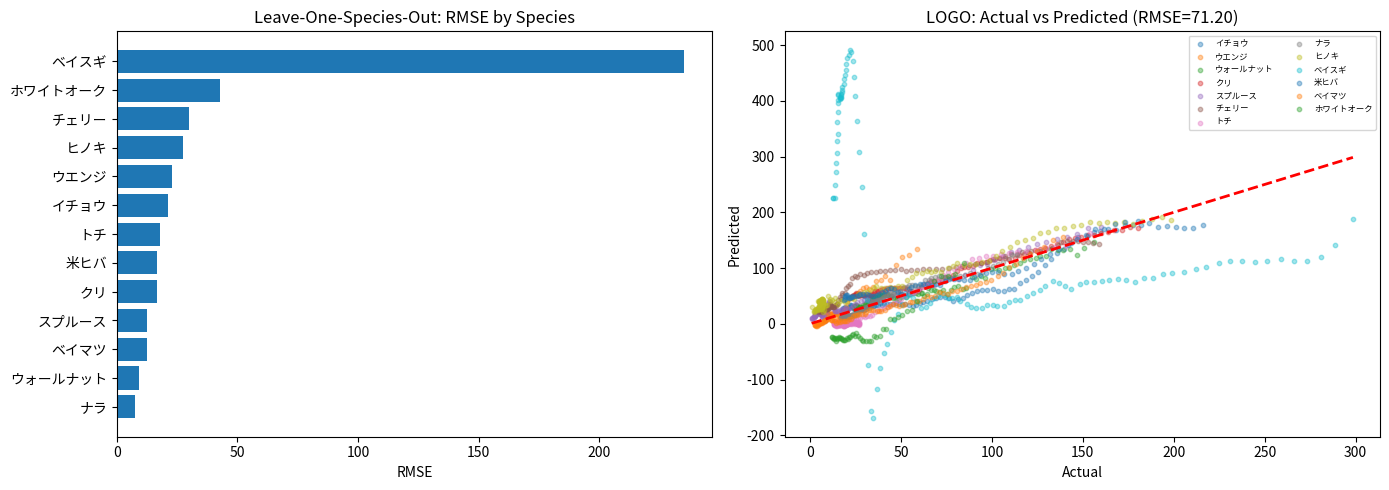


分析完了！次のステップの方向性:

1. GroupKFold RMSE >> Random KFold RMSE なら → 樹種過学習が深刻
2. LOGO で特定樹種のRMSEが突出 → その樹種の特性を分析
3. 前処理で2次微分が良い → ベースライン変動が大きい
4. PLS > LightGBM (GroupCV) → 線形モデルの方が汎化しやすい可能性

→ これらの結果を見て、Step 2 の改善方針を決めましょう！



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.model_selection import KFold, GroupKFold, LeaveOneGroupOut
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. データ読み込みと基本設定
# ============================================================
df = pd.read_csv("data/train.csv", encoding='cp932')

target_col = "含水率"
meta_cols = ["sample number", "species number", "樹種", "含水率"]
spectrum_cols = [c for c in df.columns if c not in meta_cols]
wavenumbers = np.array([float(c) for c in spectrum_cols])

X_raw = df[spectrum_cols].to_numpy(dtype=float)
y = df[target_col].values
species = df["species number"].values
species_names = df["樹種"].values

print(f"データ形状: {X_raw.shape}")
print(f"含水率範囲: {y.min():.1f} ~ {y.max():.1f} %")
print(f"樹種数: {len(np.unique(species))}")
print(f"樹種一覧: {df['樹種'].unique()}")

# ============================================================
# 2. 前処理関数の定義
# ============================================================
def snv(X):
    """Standard Normal Variate"""
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    std[std == 0] = 1.0
    return (X - mean) / std

def msc(X, ref=None):
    """Multiplicative Scatter Correction"""
    if ref is None:
        ref = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(ref, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc, ref

def sg_deriv(X, window=17, polyorder=2, deriv=1):
    """Savitzky-Golay微分"""
    return savgol_filter(X, window_length=window, polyorder=polyorder, deriv=deriv, axis=1)

def sg_smooth(X, window=17, polyorder=2):
    """Savitzky-Golayスムージング"""
    return savgol_filter(X, window_length=window, polyorder=polyorder, deriv=0, axis=1)

# ============================================================
# 3. 複数の前処理パイプラインを定義
# ============================================================
preprocess_configs = {
    "raw": lambda X: X,
    "SNV": lambda X: snv(X),
    "SNV+SG1d": lambda X: sg_deriv(snv(X), window=17, polyorder=2, deriv=1),
    "SNV+SG2d": lambda X: sg_deriv(snv(X), window=21, polyorder=3, deriv=2),
    "MSC+SG1d": lambda X: sg_deriv(msc(X)[0], window=17, polyorder=2, deriv=1),
    "SG2d_only": lambda X: sg_deriv(X, window=21, polyorder=3, deriv=2),
}

# ============================================================
# 4. 水の吸収帯に基づく特徴量エンジニアリング
# ============================================================
def extract_water_features(X_spec, wavenums):
    """
    水の吸収帯に着目した特徴量を抽出
    - ~5150-5250 cm⁻¹: OH結合音 (曲げ+伸縮)
    - ~6800-7100 cm⁻¹: OH第一倍音
    - ~8300-8700 cm⁻¹: OH第二倍音 / 結合音
    """
    features = {}
    
    # 各帯域の平均吸光度
    bands = {
        "OH_comb":    (5050, 5350),    # OH結合音
        "OH_1st":     (6700, 7200),    # OH第一倍音
        "OH_2nd":     (8200, 8800),    # OH第二倍音
        "CH_1st":     (5600, 6000),    # CH第一倍音（木材成分）
        "CH_comb":    (4000, 4500),    # CH結合音
        "baseline_h": (9000, 9500),    # ベースライン参照（高波数側）
    }
    
    for name, (lo, hi) in bands.items():
        mask = (wavenums >= lo) & (wavenums <= hi)
        if mask.sum() > 0:
            features[f"{name}_mean"] = X_spec[:, mask].mean(axis=1)
            features[f"{name}_max"] = X_spec[:, mask].max(axis=1)
            features[f"{name}_std"] = X_spec[:, mask].std(axis=1)
            # ピーク位置（波数）
            features[f"{name}_peak_pos"] = wavenums[mask][X_spec[:, mask].argmax(axis=1)]
    
    # バンド比（水 vs 木材成分）→ 樹種に依存しにくい
    if "OH_comb_mean" in features and "CH_1st_mean" in features:
        features["OH_comb_div_CH"] = features["OH_comb_mean"] / (features["CH_1st_mean"] + 1e-8)
        features["OH_1st_div_CH"] = features["OH_1st_mean"] / (features["CH_1st_mean"] + 1e-8)
    
    # 全体のベースラインレベル（散乱の影響指標）
    features["overall_mean"] = X_spec.mean(axis=1)
    features["overall_std"] = X_spec.std(axis=1)
    
    return pd.DataFrame(features)

# ============================================================
# 5. 3種類のCV戦略
# ============================================================
def evaluate_cv(X, y, species, model_fn, cv_type="random", n_splits=5, seed=42):
    """
    3種類のCV:
    - random: ランダムKFold（楽観的）
    - group:  GroupKFold by species（現実的）
    - logo:   Leave-One-Group-Out（最も厳密）
    """
    if cv_type == "random":
        cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = cv.split(X, y)
    elif cv_type == "group":
        cv = GroupKFold(n_splits=n_splits)
        splits = cv.split(X, y, groups=species)
    elif cv_type == "logo":
        cv = LeaveOneGroupOut()
        splits = cv.split(X, y, groups=species)
    else:
        raise ValueError(f"Unknown cv_type: {cv_type}")
    
    oof = np.full(len(y), np.nan)
    fold_scores = []
    
    for fold, (tr_idx, va_idx) in enumerate(splits):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        
        model = model_fn()
        model.fit(X_tr, y_tr)
        preds = model.predict(X_va).ravel()
        oof[va_idx] = preds
        
        rmse = np.sqrt(mean_squared_error(y_va, preds))
        r2 = r2_score(y_va, preds)
        fold_scores.append({"fold": fold, "rmse": rmse, "r2": r2,
                           "val_species": np.unique(species[va_idx])})
    
    valid_mask = ~np.isnan(oof)
    overall_rmse = np.sqrt(mean_squared_error(y[valid_mask], oof[valid_mask]))
    overall_r2 = r2_score(y[valid_mask], oof[valid_mask])
    
    return {
        "overall_rmse": overall_rmse,
        "overall_r2": overall_r2,
        "fold_scores": fold_scores,
        "oof": oof
    }

# ============================================================
# 6. まず「Random CV vs Group CV」の差を確認
# ============================================================
print("=" * 70)
print("STEP 1: CV戦略の比較（現状把握）")
print("=" * 70)

# SNV + SG1d 前処理
X_processed = sg_deriv(snv(X_raw), window=17, polyorder=2, deriv=1)

# PLS (n_components=10)
def make_pls():
    return PLSRegression(n_components=10)

# LightGBM（species number なし）
def make_lgb():
    return LGBMRegressor(
        objective="regression", n_estimators=300, learning_rate=0.05,
        num_leaves=31, feature_fraction=0.8, bagging_fraction=0.8,
        bagging_freq=5, verbosity=-1, random_state=42
    )

for model_name, model_fn in [("PLS(10)", make_pls), ("LightGBM", make_lgb)]:
    print(f"\n--- {model_name} ---")
    for cv_type in ["random", "group"]:
        result = evaluate_cv(X_processed, y, species, model_fn, cv_type=cv_type)
        print(f"  {cv_type:8s} CV | RMSE: {result['overall_rmse']:8.3f} | R²: {result['overall_r2']:.4f}")
        if cv_type == "group":
            for fs in result['fold_scores']:
                sp_names = [df.loc[df['species number']==s, '樹種'].iloc[0] 
                           for s in fs['val_species']]
                print(f"    Fold {fs['fold']}: RMSE={fs['rmse']:.2f}, "
                      f"Species={sp_names}")

# ============================================================
# 7. 前処理の比較（GroupKFold基準）
# ============================================================
print("\n" + "=" * 70)
print("STEP 2: 前処理の比較（GroupKFold基準）")
print("=" * 70)

results_summary = []

for prep_name, prep_fn in preprocess_configs.items():
    X_prep = prep_fn(X_raw.copy())
    
    for model_name, model_fn in [("PLS(10)", make_pls), ("LightGBM", make_lgb)]:
        result = evaluate_cv(X_prep, y, species, model_fn, cv_type="group")
        results_summary.append({
            "preprocess": prep_name,
            "model": model_name,
            "rmse": result["overall_rmse"],
            "r2": result["overall_r2"]
        })

results_df = pd.DataFrame(results_summary)
print("\n前処理 × モデル 比較表:")
pivot = results_df.pivot_table(values="rmse", index="preprocess", columns="model")
print(pivot.round(3).to_string())

# ============================================================
# 8. 水吸収帯の特徴量 + PLS のハイブリッド
# ============================================================
print("\n" + "=" * 70)
print("STEP 3: 水吸収帯の特徴量エンジニアリング")
print("=" * 70)

# Raw スペクトルから水の特徴量を抽出
water_features = extract_water_features(X_raw, wavenumbers)
print(f"水吸収帯特徴量: {water_features.shape[1]}個")
print(f"特徴量一覧: {list(water_features.columns)}")

# SNV+SG1d スペクトル + 水吸収帯特徴量
X_combined = np.hstack([X_processed, water_features.values])

def make_ridge():
    return Ridge(alpha=1.0)

for model_name, model_fn in [("PLS(10)", make_pls), ("LightGBM", make_lgb), ("Ridge", make_ridge)]:
    result = evaluate_cv(X_combined, y, species, model_fn, cv_type="group")
    print(f"  {model_name:12s} | GroupCV RMSE: {result['overall_rmse']:8.3f} | R²: {result['overall_r2']:.4f}")

# ============================================================
# 9. LOGO（Leave-One-Species-Out）で詳細分析
# ============================================================
print("\n" + "=" * 70)
print("STEP 4: Leave-One-Species-Out（樹種ごとの汎化性能）")
print("=" * 70)

result_logo = evaluate_cv(X_processed, y, species, make_pls, cv_type="logo")

print(f"\n全体 RMSE: {result_logo['overall_rmse']:.3f}")
print(f"全体 R²:   {result_logo['overall_r2']:.4f}")
print("\n樹種別の詳細:")

logo_details = []
for fs in result_logo['fold_scores']:
    for s in fs['val_species']:
        sp_name = df.loc[df['species number']==s, '樹種'].iloc[0]
        logo_details.append({
            "species": sp_name,
            "species_num": s,
            "rmse": fs['rmse'],
            "r2": fs['r2'],
            "n_samples": (species == s).sum()
        })

logo_df = pd.DataFrame(logo_details).sort_values("rmse", ascending=False)
print(logo_df.to_string(index=False))

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LOGO RMSE by species
ax = axes[0]
ax.barh(logo_df['species'], logo_df['rmse'])
ax.set_xlabel('RMSE')
ax.set_title('Leave-One-Species-Out: RMSE by Species')
ax.invert_yaxis()

# OOF予測 vs 実測（樹種で色分け）
ax = axes[1]
oof = result_logo['oof']
valid = ~np.isnan(oof)
for sp_num in np.unique(species):
    mask = (species == sp_num) & valid
    sp_name = df.loc[df['species number']==sp_num, '樹種'].iloc[0]
    ax.scatter(y[mask], oof[mask], alpha=0.4, s=10, label=sp_name)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'LOGO: Actual vs Predicted (RMSE={result_logo["overall_rmse"]:.2f})')
ax.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.savefig("step1_cv_comparison.png", dpi=150)
plt.show()

print("\n" + "=" * 70)
print("分析完了！次のステップの方向性:")
print("=" * 70)
print("""
1. GroupKFold RMSE >> Random KFold RMSE なら → 樹種過学習が深刻
2. LOGO で特定樹種のRMSEが突出 → その樹種の特性を分析
3. 前処理で2次微分が良い → ベースライン変動が大きい
4. PLS > LightGBM (GroupCV) → 線形モデルの方が汎化しやすい可能性

→ これらの結果を見て、Step 2 の改善方針を決めましょう！
""")

📂 データ読み込み中...
  データ形状: (1322, 1555)
  含水率範囲: 0.8 ~ 298.6 %
  樹種数: 13

🔍 GPU確認中...
  ✅ GPU利用可能！

🚀 STEP 1: CatBoost vs LightGBM 比較  [Device: GPU]


📊 実験進捗:   8%|██▌                           | 1/12 [00:50<09:15, 50.47s/it, SG2d_only + CatBoost(d8)]

  ✅ SG2d_only    + CatBoost(d6)     | RMSE:   22.45 | R²: 0.7945 | ⏱ 50.4s


📊 実験進捗:  17%|█████                         | 2/12 [05:43<32:10, 193.08s/it, SG2d_only + CatBoost(d4)]   

  ✅ SG2d_only    + CatBoost(d8)     | RMSE:   23.38 | R²: 0.7771 | ⏱ 292.9s


...

  ✅ SNV+SG1d     + CatBoost(d4)     | RMSE:   21.91 | R²: 0.8043 | ⏱ 53.9s
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[39]	valid_0's l2: 288.224
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[80]	valid_0's l2: 265.774
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[115]	valid_0's l2: 2103.42
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[126]	valid_0's l2: 209.495
Training until validation scores don't improve for 50 rounds


📊 実験進捗: 100%|██████████████████████████████| 12/12 [25:36<00:00, 128.00s/it, SNV+SG1d + LightGBM]    


Early stopping, best iteration is:
[52]	valid_0's l2: 182.273
  ✅ SNV+SG1d     + LightGBM         | RMSE:   24.43 | R²: 0.7567 | ⏱ 11.0s

📋 比較表（GroupKFold RMSE）
model       CatBoost(d4)  CatBoost(d6)  CatBoost(d8)  LightGBM
preprocess                                                    
SG2d_only          20.82         22.45         23.38     20.24
SNV+SG1d           21.91         22.52         23.75     24.43
SNV+SG2d           23.04         24.01         25.48     21.00

⏱ 計算時間（秒）:
model       CatBoost(d4)  CatBoost(d6)  CatBoost(d8)  LightGBM
preprocess                                                    
SG2d_only           40.7          50.4         292.9      12.3
SNV+SG1d            53.9          55.2         484.9      11.0
SNV+SG2d            44.9          43.2         424.0      22.4

🏆 ベスト: SG2d_only + LightGBM → RMSE: 20.241 (12.3s)

🔧 STEP 2: CatBoost Optuna探索 [Device: GPU]


🔍 Optuna探索: 100%|██████████████████████████████| 50/50 [48:17<00:00, 57.96s/it, Best RMSE: 17.266 | This: 19.255]   



🏆 ベストパラメータ:
  learning_rate: 0.012064
  depth: 3
  l2_leaf_reg: 8.441087
  bagging_temperature: 0.599068
  random_strength: 1.279867
  border_count: 47
  GroupKFold RMSE: 17.266

📈 STEP 3: ベストCatBoostの詳細評価
  全体 RMSE: 19.672
  全体 R²:   0.8422
  Fold 0: RMSE=16.26, Species=['チェリー', 'トチ']
  Fold 1: RMSE=8.65, Species=['クリ', 'ヒノキ']
  Fold 2: RMSE=35.82, Species=['ベイスギ', 'ベイマツ', 'ホワイトオーク']
  Fold 3: RMSE=14.29, Species=['イチョウ', 'ウエンジ', 'ウォールナット']
  Fold 4: RMSE=11.31, Species=['スプルース', 'ナラ', '米ヒバ']

🤝 STEP 4: CatBoost + LightGBM アンサンブル
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[55]	valid_0's l2: 277.639
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[158]	valid_0's l2: 168.003
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[135]	valid_0's l2: 1276.39
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration

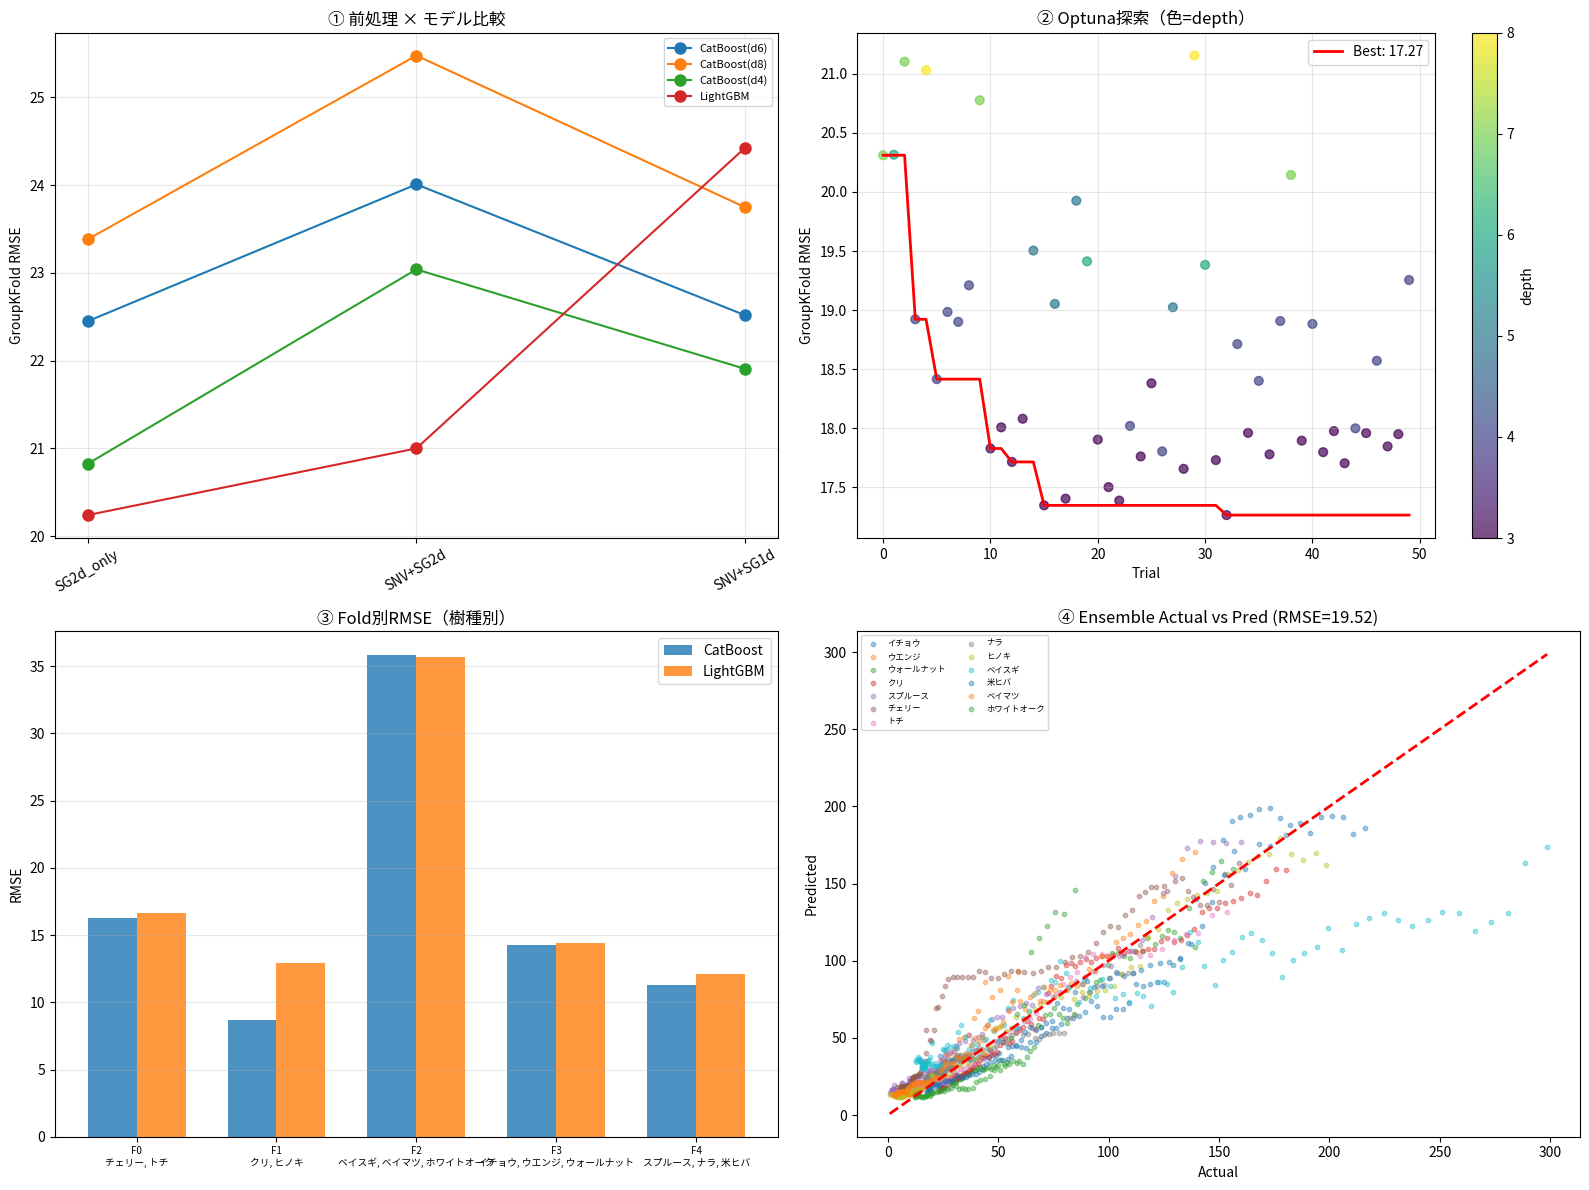


📊 最終サマリー
                          設定      RMSE        R²       時間(s)
 Ensemble(Cat×0.70+LGB×0.30) 19.517055         -           -
SG2d_only + CatBoost(Optuna) 19.672275  0.842215           -
        SG2d_only + LightGBM 20.240958  0.832961   12.300755
    SG2d_only + CatBoost(d4) 20.824916  0.823184   40.670464
         SNV+SG2d + LightGBM 21.000887  0.820183   22.378673
     SNV+SG1d + CatBoost(d4) 21.907054   0.80433   53.920515
    SG2d_only + CatBoost(d6) 22.449715  0.794516   50.414934
     SNV+SG1d + CatBoost(d6) 22.518213   0.79326   55.248849
     SNV+SG2d + CatBoost(d4) 23.041008  0.783549   44.946069
    SG2d_only + CatBoost(d8) 23.383102  0.777074  292.898159
     SNV+SG1d + CatBoost(d8) 23.748470  0.770053   484.93755
     SNV+SG2d + CatBoost(d6) 24.009742  0.764966   43.248775
         SNV+SG1d + LightGBM 24.426625  0.756733   10.954431
     SNV+SG2d + CatBoost(d8) 25.477205  0.735358  423.962515

🎯 チームメンバー Public Score: 15
   現在のベスト GroupKFold RMSE: 19.5



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. データ読み込みと前処理
# ============================================================
print("📂 データ読み込み中...")
df = pd.read_csv("data/train.csv", encoding='cp932')

target_col = "含水率"
meta_cols = ["sample number", "species number", "樹種", "含水率"]
spectrum_cols = [c for c in df.columns if c not in meta_cols]
wavenumbers = np.array([float(c) for c in spectrum_cols])

X_raw = df[spectrum_cols].to_numpy(dtype=float)
y = df[target_col].values
species = df["species number"].values

print(f"  データ形状: {X_raw.shape}")
print(f"  含水率範囲: {y.min():.1f} ~ {y.max():.1f} %")
print(f"  樹種数: {len(np.unique(species))}")

# --- 前処理関数 ---
def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    std[std == 0] = 1.0
    return (X - mean) / std

def sg_deriv(X, window=21, polyorder=3, deriv=2):
    return savgol_filter(X, window_length=window, polyorder=polyorder,
                         deriv=deriv, axis=1)

preprocess_configs = {
    "SG2d_only":  lambda X: sg_deriv(X, window=21, polyorder=3, deriv=2),
    "SNV+SG2d":   lambda X: sg_deriv(snv(X), window=21, polyorder=3, deriv=2),
    "SNV+SG1d":   lambda X: sg_deriv(snv(X), window=17, polyorder=2, deriv=1),
}

# ============================================================
# 2. GPU確認
# ============================================================
print("\n🔍 GPU確認中...")
try:
    test_model = CatBoostRegressor(task_type="GPU", iterations=10, verbose=0)
    test_model.fit(X_raw[:10], y[:10])
    USE_GPU = True
    print("  ✅ GPU利用可能！")
except Exception as e:
    USE_GPU = False
    print(f"  ⚠️ GPU利用不可、CPUで実行します: {e}")

TASK_TYPE = "GPU" if USE_GPU else "CPU"

# ============================================================
# 3. 評価関数（進捗表示付き）
# ============================================================
def evaluate_model_groupcv(X, y, species, model_fn, n_splits=5, desc=""):
    """GroupKFoldで評価（進捗バー付き）"""
    cv = GroupKFold(n_splits=n_splits)
    oof = np.full(len(y), np.nan)
    fold_scores = []
    models = []

    splits = list(cv.split(X, y, groups=species))
    
    for fold, (tr_idx, va_idx) in enumerate(splits):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        model = model_fn()

        if isinstance(model, CatBoostRegressor):
            model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=0)
        elif isinstance(model, LGBMRegressor):
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                      callbacks=[__import__('lightgbm').early_stopping(50),
                                 __import__('lightgbm').log_evaluation(0)])
        else:
            model.fit(X_tr, y_tr)

        preds = model.predict(X_va).ravel()
        oof[va_idx] = preds
        models.append(model)

        rmse = np.sqrt(mean_squared_error(y_va, preds))
        fold_scores.append(rmse)

    valid = ~np.isnan(oof)
    overall_rmse = np.sqrt(mean_squared_error(y[valid], oof[valid]))
    overall_r2 = r2_score(y[valid], oof[valid])

    return {"rmse": overall_rmse, "r2": overall_r2,
            "fold_scores": fold_scores, "oof": oof, "models": models}

# ============================================================
# 4. CatBoost vs LightGBM 比較（進捗バー付き）
# ============================================================
print("\n" + "=" * 70)
print(f"🚀 STEP 1: CatBoost vs LightGBM 比較  [Device: {TASK_TYPE}]")
print("=" * 70)

model_configs = {
    "CatBoost(d6)": lambda: CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=6,
        l2_leaf_reg=3, random_seed=42, verbose=0,
        early_stopping_rounds=50, task_type=TASK_TYPE,
    ),
    "CatBoost(d8)": lambda: CatBoostRegressor(
        iterations=2000, learning_rate=0.03, depth=8,
        l2_leaf_reg=5, random_seed=42, verbose=0,
        early_stopping_rounds=100, task_type=TASK_TYPE,
    ),
    "CatBoost(d4)": lambda: CatBoostRegressor(
        iterations=2000, learning_rate=0.03, depth=4,
        l2_leaf_reg=10, random_seed=42, verbose=0,
        early_stopping_rounds=100, task_type=TASK_TYPE,
    ),
    "LightGBM": lambda: LGBMRegressor(
        objective="regression", n_estimators=1000, learning_rate=0.05,
        num_leaves=31, feature_fraction=0.8, bagging_fraction=0.8,
        bagging_freq=5, verbosity=-1, random_state=42,
    ),
}

# 全組み合わせ数を計算
total_experiments = len(preprocess_configs) * len(model_configs)
results = []

# tqdmで全体進捗を表示
pbar = tqdm(total=total_experiments, desc="📊 実験進捗", 
            bar_format='{l_bar}{bar:30}{r_bar}')

for prep_name, prep_fn in preprocess_configs.items():
    X_prep = prep_fn(X_raw.copy())

    for model_name, model_fn in model_configs.items():
        pbar.set_postfix_str(f"{prep_name} + {model_name}")
        
        t_start = time.time()
        result = evaluate_model_groupcv(X_prep, y, species, model_fn)
        elapsed = time.time() - t_start

        results.append({
            "preprocess": prep_name,
            "model": model_name,
            "rmse": result["rmse"],
            "r2": result["r2"],
            "fold_scores": result["fold_scores"],
            "oof": result["oof"],
            "models": result["models"],
            "time": elapsed,
        })

        # 各実験の結果をリアルタイム表示
        tqdm.write(
            f"  ✅ {prep_name:12s} + {model_name:16s} | "
            f"RMSE: {result['rmse']:7.2f} | R²: {result['r2']:.4f} | "
            f"⏱ {elapsed:.1f}s"
        )
        pbar.update(1)

pbar.close()

# --- 結果一覧表 ---
print("\n" + "=" * 70)
print("📋 比較表（GroupKFold RMSE）")
print("=" * 70)
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['oof', 'models', 'fold_scores']}
    for r in results
])
pivot = results_df.pivot_table(values="rmse", index="preprocess", columns="model")
print(pivot.round(2).to_string())

# 時間の表も
pivot_time = results_df.pivot_table(values="time", index="preprocess", columns="model")
print("\n⏱ 計算時間（秒）:")
print(pivot_time.round(1).to_string())

best = min(results, key=lambda x: x['rmse'])
print(f"\n🏆 ベスト: {best['preprocess']} + {best['model']} → RMSE: {best['rmse']:.3f} ({best['time']:.1f}s)")

# ============================================================
# 5. Optunaハイパーパラメータ探索（進捗バー付き）
# ============================================================
print("\n" + "=" * 70)
print(f"🔧 STEP 2: CatBoost Optuna探索 [Device: {TASK_TYPE}]")
print("=" * 70)

best_prep_name = best['preprocess']
X_best = preprocess_configs[best_prep_name](X_raw.copy())

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 探索履歴を保存（可視化用）
search_history = []

def objective(trial):
    params = {
        "iterations": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 30, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_strength": trial.suggest_float("random_strength", 0, 10),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_seed": 42,
        "verbose": 0,
        "early_stopping_rounds": 100,
        "task_type": TASK_TYPE,
    }

    cv = GroupKFold(n_splits=5)
    fold_rmses = []

    for tr_idx, va_idx in cv.split(X_best, y, groups=species):
        model = CatBoostRegressor(**params)
        model.fit(X_best[tr_idx], y[tr_idx],
                  eval_set=(X_best[va_idx], y[va_idx]),
                  verbose=0)
        preds = model.predict(X_best[va_idx])
        fold_rmses.append(np.sqrt(mean_squared_error(y[va_idx], preds)))

    mean_rmse = np.mean(fold_rmses)
    search_history.append({
        "trial": trial.number,
        "rmse": mean_rmse,
        "depth": params["depth"],
        "lr": params["learning_rate"],
    })
    return mean_rmse

# tqdm付きのOptuna探索
n_trials = 50
pbar_optuna = tqdm(total=n_trials, desc="🔍 Optuna探索",
                   bar_format='{l_bar}{bar:30}{r_bar}')

best_so_far = float('inf')

def optuna_callback(study, trial):
    global best_so_far
    pbar_optuna.update(1)
    if trial.value < best_so_far:
        best_so_far = trial.value
        pbar_optuna.set_postfix_str(f"Best RMSE: {best_so_far:.3f} (trial {trial.number})")
    else:
        pbar_optuna.set_postfix_str(
            f"Best RMSE: {best_so_far:.3f} | This: {trial.value:.3f}"
        )

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=n_trials, callbacks=[optuna_callback])
pbar_optuna.close()

print(f"\n🏆 ベストパラメータ:")
for k, v in study.best_params.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.6f}")
    else:
        print(f"  {k}: {v}")
print(f"  GroupKFold RMSE: {study.best_value:.3f}")

# ============================================================
# 6. ベストパラメータで最終評価
# ============================================================
print("\n" + "=" * 70)
print("📈 STEP 3: ベストCatBoostの詳細評価")
print("=" * 70)

best_params = study.best_params.copy()
best_params.update({
    "iterations": 2000,
    "random_seed": 42,
    "verbose": 0,
    "early_stopping_rounds": 100,
    "task_type": TASK_TYPE,
})

def make_best_catboost():
    return CatBoostRegressor(**best_params)

result_best = evaluate_model_groupcv(X_best, y, species, make_best_catboost)

print(f"  全体 RMSE: {result_best['rmse']:.3f}")
print(f"  全体 R²:   {result_best['r2']:.4f}")

cv = GroupKFold(n_splits=5)
for fold, ((tr_idx, va_idx), rmse) in enumerate(
        zip(cv.split(X_best, y, groups=species), result_best['fold_scores'])):
    val_species = np.unique(species[va_idx])
    sp_names = [df.loc[df['species number'] == s, '樹種'].iloc[0] for s in val_species]
    print(f"  Fold {fold}: RMSE={rmse:.2f}, Species={sp_names}")

# ============================================================
# 7. アンサンブル: CatBoost + LightGBM
# ============================================================
print("\n" + "=" * 70)
print("🤝 STEP 4: CatBoost + LightGBM アンサンブル")
print("=" * 70)

def make_lgb():
    return LGBMRegressor(
        objective="regression", n_estimators=1000, learning_rate=0.05,
        num_leaves=31, feature_fraction=0.8, bagging_fraction=0.8,
        bagging_freq=5, verbosity=-1, random_state=42,
    )

result_lgb = evaluate_model_groupcv(X_best, y, species, make_lgb)

oof_cat = result_best['oof']
oof_lgb = result_lgb['oof']

best_w, best_ens_rmse = 0.5, 999
for w in np.arange(0.0, 1.01, 0.05):
    oof_ens = w * oof_cat + (1 - w) * oof_lgb
    valid = ~np.isnan(oof_ens)
    rmse_ens = np.sqrt(mean_squared_error(y[valid], oof_ens[valid]))
    if rmse_ens < best_ens_rmse:
        best_ens_rmse = rmse_ens
        best_w = w

print(f"  CatBoost単体:  RMSE = {result_best['rmse']:.3f}")
print(f"  LightGBM単体:  RMSE = {result_lgb['rmse']:.3f}")
print(f"  アンサンブル:   RMSE = {best_ens_rmse:.3f}  (CatBoost重み: {best_w:.2f})")

# ============================================================
# 8. 可視化（4パネル）
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- (1) モデル × 前処理 比較 ---
ax = axes[0, 0]
for model_name in results_df['model'].unique():
    subset = results_df[results_df['model'] == model_name]
    ax.plot(subset['preprocess'], subset['rmse'], 'o-', label=model_name, markersize=8)
ax.set_ylabel('GroupKFold RMSE')
ax.set_title('① 前処理 × モデル比較')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3)

# --- (2) Optuna探索過程 ---
ax = axes[0, 1]
hist_df = pd.DataFrame(search_history)
scatter = ax.scatter(hist_df['trial'], hist_df['rmse'],
                     c=hist_df['depth'], cmap='viridis', alpha=0.7, s=40)
# best 推移線
best_line = hist_df['rmse'].cummin()
ax.plot(hist_df['trial'], best_line, 'r-', lw=2, label=f'Best: {study.best_value:.2f}')
ax.set_xlabel('Trial')
ax.set_ylabel('GroupKFold RMSE')
ax.set_title('② Optuna探索（色=depth）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='depth')

# --- (3) Fold別RMSE比較 ---
ax = axes[1, 0]
cv = GroupKFold(n_splits=5)
fold_labels = []
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_best, y, groups=species)):
    val_species = np.unique(species[va_idx])
    sp_names = [df.loc[df['species number'] == s, '樹種'].iloc[0] for s in val_species]
    fold_labels.append(f"F{fold}\n{', '.join(sp_names)}")

x_pos = np.arange(5)
width = 0.35
ax.bar(x_pos - width/2, result_best['fold_scores'], width, label='CatBoost', alpha=0.8)
ax.bar(x_pos + width/2, result_lgb['fold_scores'], width, label='LightGBM', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(fold_labels, fontsize=7)
ax.set_ylabel('RMSE')
ax.set_title('③ Fold別RMSE（樹種別）')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# --- (4) アンサンブル Actual vs Predicted ---
ax = axes[1, 1]
oof_final = best_w * oof_cat + (1 - best_w) * oof_lgb
valid = ~np.isnan(oof_final)
for sp_num in np.unique(species):
    mask = (species == sp_num) & valid
    sp_name = df.loc[df['species number'] == sp_num, '樹種'].iloc[0]
    ax.scatter(y[mask], oof_final[mask], alpha=0.4, s=10, label=sp_name)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'④ Ensemble Actual vs Pred (RMSE={best_ens_rmse:.2f})')
ax.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.savefig("step2_catboost_full_results.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 9. 最終サマリー
# ============================================================
print("\n" + "=" * 70)
print("📊 最終サマリー")
print("=" * 70)

# 全結果をソートして表示
all_results = []
for r in results:
    all_results.append({
        "設定": f"{r['preprocess']} + {r['model']}",
        "RMSE": r['rmse'],
        "R²": r['r2'],
        "時間(s)": r['time'],
    })
all_results.append({"設定": f"{best_prep_name} + CatBoost(Optuna)", 
                     "RMSE": result_best['rmse'], "R²": result_best['r2'], "時間(s)": "-"})
all_results.append({"設定": f"Ensemble(Cat×{best_w:.2f}+LGB×{1-best_w:.2f})",
                     "RMSE": best_ens_rmse, "R²": "-", "時間(s)": "-"})

summary_df = pd.DataFrame(all_results).sort_values("RMSE")
print(summary_df.to_string(index=False))

print(f"""
{'='*70}
🎯 チームメンバー Public Score: 15
   現在のベスト GroupKFold RMSE: {min(result_best['rmse'], best_ens_rmse):.1f}
{'='*70}
""")